# Exercise 1: Word Embeddings and Cosine Similarity, SOLUTION

In this exercise, you will explore **word embeddings**, dense vector representations of words that capture semantic meaning. You will:

- Understand why we need word embeddings (vs. one-hot encoding)
- Load pretrained **Word2Vec** embeddings
- Implement **cosine similarity** from scratch
- Explore word analogies (e.g., king - man + woman = queen)
- Visualize word embeddings in 2D using **t-SNE**
- Build a simple trainable embedding layer in PyTorch

# **Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
import gensim.downloader as api

# **1. Why Word Embeddings?**

In NLP, we need to represent words as numbers so that models can process them.

The simplest approach is **one-hot encoding**: each word is a vector of size `V` (vocabulary size) with a single 1 and the rest 0s.

**Problems with one-hot encoding:**
- Vectors are **very high-dimensional** (vocabulary can be 50,000+ words)
- All word pairs have the **same distance**, "cat" is as far from "dog" as it is from "airplane"
- No notion of **semantic similarity**

**Word embeddings** solve this by mapping each word to a **dense, low-dimensional vector** (e.g., 100-300 dimensions) where semantically similar words are close together.

Let's first see the problem with one-hot encoding.

In [2]:
# One-hot encoding example
vocabulary = ['cat', 'dog', 'airplane', 'car', 'kitten']
vocab_size = len(vocabulary)

# Create one-hot vectors
one_hot = np.eye(vocab_size)
word_to_onehot = {word: one_hot[i] for i, word in enumerate(vocabulary)}

print("One-hot encoding:")
for word, vec in word_to_onehot.items():
    print(f"  {word:10s} -> {vec}")

# Compute dot products between all pairs
print("\nDot products (similarity) between one-hot vectors:")
for i, w1 in enumerate(vocabulary):
    for j, w2 in enumerate(vocabulary):
        if i < j:
            dot = np.dot(word_to_onehot[w1], word_to_onehot[w2])
            print(f"  {w1:10s} . {w2:10s} = {dot}")

print("\n=> All pairs have dot product = 0. No similarity information!")

One-hot encoding:
  cat        -> [1. 0. 0. 0. 0.]
  dog        -> [0. 1. 0. 0. 0.]
  airplane   -> [0. 0. 1. 0. 0.]
  car        -> [0. 0. 0. 1. 0.]
  kitten     -> [0. 0. 0. 0. 1.]

Dot products (similarity) between one-hot vectors:
  cat        . dog        = 0.0
  cat        . airplane   = 0.0
  cat        . car        = 0.0
  cat        . kitten     = 0.0
  dog        . airplane   = 0.0
  dog        . car        = 0.0
  dog        . kitten     = 0.0
  airplane   . car        = 0.0
  airplane   . kitten     = 0.0
  car        . kitten     = 0.0

=> All pairs have dot product = 0. No similarity information!


# **2. Load Pretrained Word2Vec Embeddings**

**Word2Vec** (Mikolov et al., 2013) is a method that learns word embeddings from large text corpora. The key idea is:

> *"You shall know a word by the company it keeps"*

Words that appear in similar contexts get similar vector representations.

We will load a pretrained Word2Vec model trained on part of the Google News dataset (~100 billion words). Each word is represented by a **300-dimensional** vector.

**Note:** The first time you run this cell, it will download the model (~66MB). This may take a few minutes.

In [3]:
# Load pretrained Word2Vec model (smaller version: 25,000 most common words)
wv = api.load('glove-wiki-gigaword-100')  # 100-dimensional GloVe vectors

print(f"Vocabulary size: {len(wv)}")
print(f"Embedding dimension: {wv.vector_size}")

Vocabulary size: 400000
Embedding dimension: 100


In [4]:
# Look at the embedding vector for a word
word = 'cat'
vector = wv[word]

print(f"Embedding for '{word}':")
print(f"  Shape: {vector.shape}")
print(f"  First 10 values: {vector[:10]}")
print(f"  Min: {vector.min():.4f}, Max: {vector.max():.4f}")

Embedding for 'cat':
  Shape: (100,)
  First 10 values: [ 0.23088   0.28283   0.6318   -0.59411  -0.58599   0.63255   0.24402
 -0.14108   0.060815 -0.7898  ]
  Min: -1.3422, Max: 1.1846


# **3. Cosine Similarity**

To measure how similar two word embeddings are, we use **cosine similarity**:

$$\text{cosine\_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

where:
- $\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$ is the dot product
- $\|\mathbf{a}\| = \sqrt{\sum_i a_i^2}$ is the L2 norm

The result is between **-1** (opposite) and **+1** (identical direction). Similar words should have values close to 1.

**Task:** Implement the cosine similarity function from scratch using NumPy.

In [5]:
def cosine_similarity(a, b):
    """
    Compute cosine similarity between two vectors.
    
    Args:
        a: numpy array of shape (d,)
        b: numpy array of shape (d,)
    Returns:
        float: cosine similarity between a and b
    """
    # SOLUTION
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

In [6]:
# Test your cosine similarity function
pairs = [
    ('cat', 'dog'),       # similar (both animals)
    ('cat', 'kitten'),    # very similar
    ('cat', 'car'),       # not similar
    ('king', 'queen'),    # similar (both royalty)
    ('king', 'banana'),   # not similar
    ('good', 'great'),    # similar (synonyms)
    ('good', 'bad'),      # related but opposite
]

print("Cosine similarities:")
for w1, w2 in pairs:
    sim = cosine_similarity(wv[w1], wv[w2])
    print(f"  {w1:10s} - {w2:10s} : {sim:.4f}")

print("\n=> Words with similar meaning have higher cosine similarity!")

Cosine similarities:
  cat        - dog        : 0.8798
  cat        - kitten     : 0.5581
  cat        - car        : 0.3110
  king       - queen      : 0.7508
  king       - banana     : 0.1609
  good       - great      : 0.7593
  good       - bad        : 0.7703

=> Words with similar meaning have higher cosine similarity!


**Question:** Why do 'good' and 'bad' still have a relatively high cosine similarity, even though they are opposites?

# **4. Finding Most Similar Words**

The pretrained model can find the words most similar to a given word by computing cosine similarity against all words in the vocabulary.

**Task:** Use the `most_similar()` method to explore the embeddings. Try different words and observe the results.

In [7]:
# Find the 5 most similar words to a given word
query_words = ['cat', 'france', 'computer', 'happy']

for word in query_words:
    similar = wv.most_similar(word, topn=5)
    print(f"\nMost similar to '{word}':")
    for sim_word, score in similar:
        print(f"  {sim_word:15s} (similarity: {score:.4f})")


Most similar to 'cat':
  dog             (similarity: 0.8798)
  rabbit          (similarity: 0.7424)
  cats            (similarity: 0.7323)
  monkey          (similarity: 0.7289)
  pet             (similarity: 0.7190)

Most similar to 'france':
  belgium         (similarity: 0.8076)
  french          (similarity: 0.8004)
  britain         (similarity: 0.7951)
  spain           (similarity: 0.7557)
  paris           (similarity: 0.7482)

Most similar to 'computer':
  computers       (similarity: 0.8752)
  software        (similarity: 0.8373)
  technology      (similarity: 0.7642)
  pc              (similarity: 0.7366)
  hardware        (similarity: 0.7290)

Most similar to 'happy':
  'm              (similarity: 0.8413)
  feel            (similarity: 0.8133)
  're             (similarity: 0.8048)
  i               (similarity: 0.7938)
  'll             (similarity: 0.7916)


# **5. Word Analogies**

One of the most fascinating properties of word embeddings is that they capture **linear relationships** between words. For example:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

This means that the vector difference between "king" and "man" captures the concept of "royalty", and adding it to "woman" gives us "queen".

**Task:** Implement the analogy function: given words A, B, and C, find word D such that A is to B as C is to D.

In [8]:
def word_analogy(wv, a, b, c):
    """
    Solve the analogy: a is to b as c is to ?
    
    The result vector is computed as: b - a + c
    Then find the word closest to this vector.
    
    Args:
        wv: word vectors model
        a, b, c: words (strings)
    Returns:
        The word that completes the analogy
    """
    # SOLUTION
    result_vector = wv[b] - wv[a] + wv[c]
    similar = wv.similar_by_vector(result_vector, topn=5)
    for word, score in similar:
        if word not in [a, b, c]:
            return word
    

In [9]:
# Test analogies
analogies = [
    ('man', 'king', 'woman'),       # Expected: queen
    ('paris', 'france', 'berlin'),   # Expected: germany
    ('slow', 'slower', 'fast'),      # Expected: faster
    ('japan', 'sushi', 'italy'),     # Expected: pizza or pasta
]

print("Word analogies (A is to B as C is to ?):")
for a, b, c in analogies:
    result = word_analogy(wv, a, b, c)
    print(f"  {a:10s} is to {b:10s} as {c:10s} is to {result}")

Word analogies (A is to B as C is to ?):
  man        is to king       as woman      is to queen
  paris      is to france     as berlin     is to germany
  slow       is to slower     as fast       is to faster
  japan      is to sushi      as italy      is to tapas


# **6. Visualize Word Embeddings with t-SNE**

Word embeddings live in a 100-dimensional space, so we cannot visualize them directly. We use **t-SNE** (t-distributed Stochastic Neighbor Embedding) to project them into 2D while preserving local structure, similar words should stay close together.

**Task:** Select groups of related words, extract their embeddings, and apply t-SNE to visualize them.

In [10]:
# Define groups of related words
word_groups = {
    'animals': ['cat', 'dog', 'horse', 'fish', 'bird', 'lion', 'tiger', 'bear'],
    'countries': ['france', 'germany', 'italy', 'spain', 'japan', 'china', 'brazil', 'canada'],
    'colors': ['red', 'blue', 'green', 'yellow', 'black', 'white', 'orange', 'purple'],
    'sports': ['football', 'basketball', 'tennis', 'swimming', 'boxing', 'cricket', 'golf', 'hockey'],
}

# Collect all words and their embeddings
all_words = []
all_vectors = []
all_colors = []
color_map = {'animals': 'red', 'countries': 'blue', 'colors': 'green', 'sports': 'orange'}

for group_name, words in word_groups.items():
    for word in words:
        all_words.append(word)
        all_vectors.append(wv[word])
        all_colors.append(color_map[group_name])

all_vectors = np.array(all_vectors)
print(f"Embedding matrix shape: {all_vectors.shape}")

Embedding matrix shape: (32, 100)


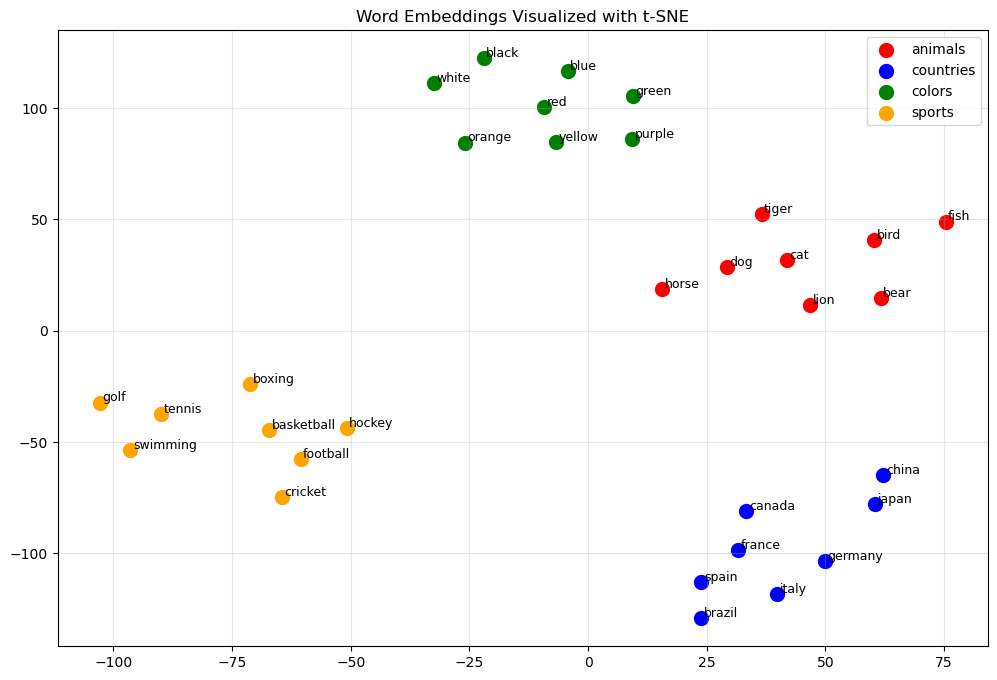

=> Words from the same category cluster together!


In [11]:
# Apply t-SNE to reduce from 100D to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=8)
vectors_2d = tsne.fit_transform(all_vectors)

# Plot
plt.figure(figsize=(12, 8))
for group_name, color in color_map.items():
    mask = [c == color for c in all_colors]
    indices = [i for i, m in enumerate(mask) if m]
    plt.scatter(vectors_2d[indices, 0], vectors_2d[indices, 1], 
                c=color, label=group_name, s=100)

# Add word labels
for i, word in enumerate(all_words):
    plt.annotate(word, (vectors_2d[i, 0]+0.5, vectors_2d[i, 1]+0.5), fontsize=9)

plt.title('Word Embeddings Visualized with t-SNE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("=> Words from the same category cluster together!")

# **7. PyTorch Embedding Layer**

In deep learning models, we use `nn.Embedding` as a **trainable lookup table** that maps word indices to dense vectors. This is the first layer in most NLP models.

Unlike pretrained Word2Vec, an `nn.Embedding` layer starts with random vectors and learns task-specific embeddings during training.

**Task:** Create an embedding layer and observe how it works.

In [12]:
# Create a simple embedding layer
vocab_size = 1000   # number of words in our vocabulary
embed_dim = 64      # dimension of each embedding vector

# SOLUTION
embedding = nn.Embedding(vocab_size, embed_dim)

print(f"Embedding weight shape: {embedding.weight.shape}")
print(f"Number of trainable parameters: {embedding.weight.numel()}")

Embedding weight shape: torch.Size([1000, 64])
Number of trainable parameters: 64000


In [13]:
# Pass word indices through the embedding layer
# Imagine these indices represent the sentence: "the cat sat"
word_indices = torch.tensor([42, 7, 156])  # 3 word indices

# SOLUTION
embedded = embedding(word_indices)

print(f"Input shape:  {word_indices.shape}")    # (3,)
print(f"Output shape: {embedded.shape}")         # (3, 64)
print(f"\nEach word index is mapped to a {embed_dim}-dimensional vector")

Input shape:  torch.Size([3])
Output shape: torch.Size([3, 64])

Each word index is mapped to a 64-dimensional vector


In [14]:
# With batches: (batch_size, sequence_length) -> (batch_size, sequence_length, embed_dim)
batch = torch.tensor([
    [42, 7, 156, 3],    # sentence 1 (4 words)
    [89, 12, 42, 7],    # sentence 2 (4 words)
])

embedded_batch = embedding(batch)
print(f"Batch input shape:  {batch.shape}")           # (2, 4)
print(f"Batch output shape: {embedded_batch.shape}")   # (2, 4, 64)
print(f"\n=> Each word in each sentence gets its own embedding vector")

Batch input shape:  torch.Size([2, 4])
Batch output shape: torch.Size([2, 4, 64])

=> Each word in each sentence gets its own embedding vector


# **8. Cosine Similarity Matrix (Bonus)**

**Task:** Compute the pairwise cosine similarity matrix for a set of words and display it as a heatmap. Use your cosine similarity function from earlier.

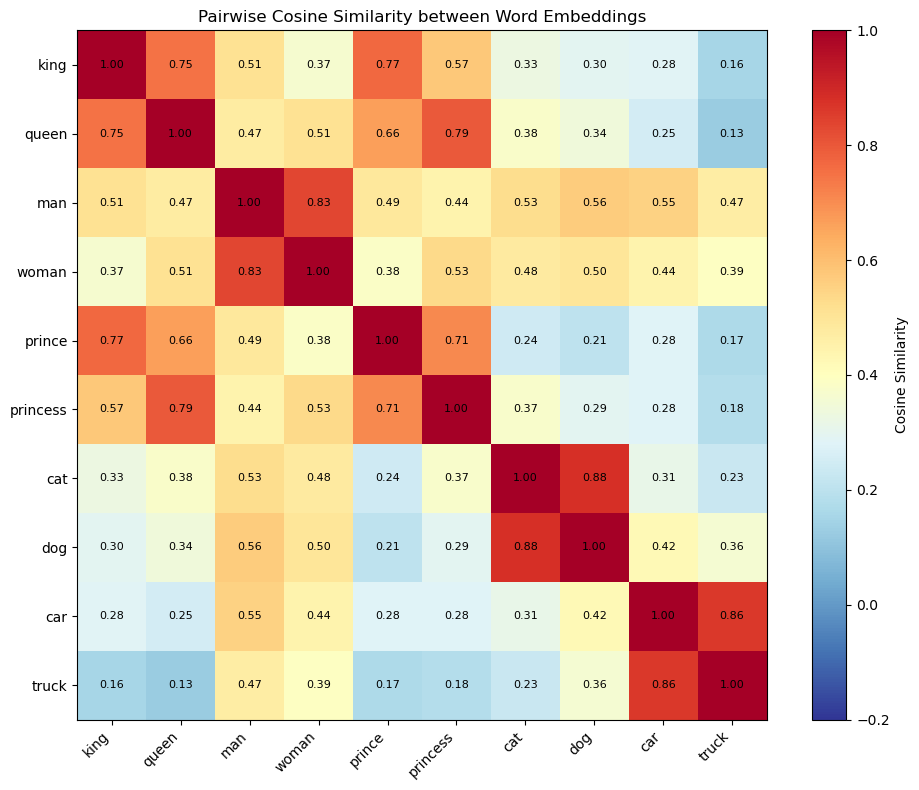

In [15]:
words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 
         'cat', 'dog', 'car', 'truck']

n = len(words)
sim_matrix = np.zeros((n, n))

# SOLUTION
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(wv[words[i]], wv[words[j]])

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(n), words, rotation=45, ha='right')
plt.yticks(range(n), words)
plt.title('Pairwise Cosine Similarity between Word Embeddings')

# Add text annotations
for i in range(n):
    for j in range(n):
        plt.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Questions to think about:**
1. Which clusters of words do you observe in the similarity matrix?
2. Why might "king" and "queen" have higher similarity than "king" and "cat"?
3. What limitations do you see in these embeddings? (Hint: think about polysemy, words with multiple meanings)